In [7]:
!pip install pandas numpy scikit-learn


In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [9]:
train = pd.read_csv("data/train_users.csv")
test = pd.read_csv("data/test_users.csv")

print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

print("\nTrain Columns:\n", train.columns)
print("\nTest Columns:\n", test.columns)

print("\nFirst 5 rows of Train:\n", train.head())
print("\nFirst 5 rows of Test:\n", test.head())


Train Shape: (2000, 33)
Test Shape : (2000, 32)

Train Columns:
 Index(['user_id', 'age', 'income', 'clicks', 'purchase_amount',
       'session_duration', 'content_variety', 'engagement_score',
       'num_transactions', 'avg_monthly_spend', 'avg_cart_value',
       'browsing_depth', 'revisit_rate', 'scroll_activity', 'time_on_site',
       'interaction_count', 'preferred_price_range', 'discount_usage_rate',
       'wishlist_size', 'product_views', 'repeat_purchase_gap (days)',
       'churn_risk_score', 'loyalty_index', 'screen_brightness',
       'battery_percentage', 'cart_abandonment_count', 'browser_version',
       'background_app_count', 'session_inactivity_duration', 'network_jitter',
       'region_code', 'subscriber', 'label'],
      dtype='object')

Test Columns:
 Index(['user_id', 'age', 'income', 'clicks', 'purchase_amount',
       'session_duration', 'content_variety', 'engagement_score',
       'num_transactions', 'avg_monthly_spend', 'avg_cart_value',
       'browsing_

In [10]:
print("\nTrain dtypes:\n", train.dtypes)
print("\nTest dtypes:\n", test.dtypes)



Train dtypes:
 user_id                         object
age                            float64
income                           int64
clicks                           int64
purchase_amount                float64
session_duration               float64
content_variety                float64
engagement_score               float64
num_transactions                 int64
avg_monthly_spend              float64
avg_cart_value                 float64
browsing_depth                   int64
revisit_rate                   float64
scroll_activity                  int64
time_on_site                   float64
interaction_count                int64
preferred_price_range          float64
discount_usage_rate            float64
wishlist_size                    int64
product_views                    int64
repeat_purchase_gap (days)     float64
churn_risk_score               float64
loyalty_index                  float64
screen_brightness              float64
battery_percentage             float64
cart_aban

In [11]:
print("\nMissing values in Train:\n", train.isnull().sum())
print("\nMissing values in Test:\n", test.isnull().sum())



Missing values in Train:
 user_id                          0
age                            698
income                           0
clicks                           0
purchase_amount                  0
session_duration                 0
content_variety                  0
engagement_score                 0
num_transactions                 0
avg_monthly_spend                0
avg_cart_value                   0
browsing_depth                   0
revisit_rate                     0
scroll_activity                  0
time_on_site                     0
interaction_count                0
preferred_price_range            0
discount_usage_rate              0
wishlist_size                    0
product_views                    0
repeat_purchase_gap (days)       0
churn_risk_score                 0
loyalty_index                    0
screen_brightness                0
battery_percentage               0
cart_abandonment_count           0
browser_version                  0
background_app_count        

In [12]:
X = train.drop(columns=['label', 'user_id'])
y = train['label']


In [13]:
X['subscriber'] = X['subscriber'].astype(int)

In [14]:
imputer = SimpleImputer(strategy='median')
X['age'] = imputer.fit_transform(X[['age']])


In [15]:
X = pd.get_dummies(
    X,
    columns=['browser_version', 'region_code'],
    drop_first=True
)


In [16]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [18]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
clf_model = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=0.5,
    max_iter=1000,
    multi_class='multinomial'
)
clf_model.fit(X_train_scaled, y_train)

C:\Users\mbfeb\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\mbfeb\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LogisticRegression(C=0.5, max_iter=1000, multi_class='multinomial',
                   penalty='l1', solver='saga')

In [20]:
y_pred = clf_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.925
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       142
           1       0.99      0.91      0.95       142
           2       0.88      1.00      0.94       116

    accuracy                           0.93       400
   macro avg       0.93      0.93      0.93       400
weighted avg       0.93      0.93      0.92       400



In [21]:
train_contexts = clf_model.predict(X_train)

C:\Users\mbfeb\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [22]:
!pip install rlcmab-sampler


In [23]:
from rlcmab_sampler import sampler

roll_number = 21  
reward_sampler = sampler(roll_number)


In [24]:
from rlcmab_sampler import sampler

roll_number = 21  
reward_sampler = sampler(roll_number)


In [25]:
import numpy as np

def epsilon_greedy(T=10000, epsilon=0.1):

    n_arms = 12   # 3 contexts × 4 categories

    counts = np.zeros(n_arms)   # how many times arm played
    values = np.zeros(n_arms)   # average reward estimate

    rewards = []

    for t in range(T):

        idx = np.random.randint(0, len(train_contexts))
        context = train_contexts[idx]


        start = context * 4
        end = start + 4

        # explore vs exploit
        if np.random.rand() < epsilon:
            action = np.random.randint(start, end)
        else:
            action = start + np.argmax(values[start:end])

        # get reward
        reward = reward_sampler.sample(action)

        # update stats
        counts[action] += 1
        values[action] += (reward - values[action]) / counts[action]

        rewards.append(reward)

    # return average reward curve
    avg_reward = np.cumsum(rewards) / np.arange(1, T+1)

    return avg_reward

In [26]:
eps_rewards = epsilon_greedy()

print("Final Average Reward:", eps_rewards[-1])

Final Average Reward: 4.525881624323524


In [27]:
def ucb(T=10000, C=2):

    n_arms = 12

    counts = np.zeros(n_arms)
    values = np.zeros(n_arms)

    rewards = []

    for t in range(T):

        idx = np.random.randint(0, len(train_contexts))
        context = train_contexts[idx]


        start = context * 4
        end = start + 4

        scores = []

        for a in range(start, end):
            if counts[a] == 0:
                scores.append(1e9)   # force exploration
            else:
                bonus = C * np.sqrt(np.log(t+1) / counts[a])
                scores.append(values[a] + bonus)

        action = start + np.argmax(scores)

        reward = reward_sampler.sample(action)

        counts[action] += 1
        values[action] += (reward - values[action]) / counts[action]

        rewards.append(reward)

    avg_reward = np.cumsum(rewards) / np.arange(1, T+1)

    return avg_reward

In [28]:
ucb_rewards = ucb()

print("Final Average Reward:", ucb_rewards[-1])

Final Average Reward: 4.91349709995559


In [29]:
def softmax_bandit(T=10000, tau=1):

    n_arms = 12

    counts = np.zeros(n_arms)
    values = np.zeros(n_arms)

    rewards = []

    for t in range(T):

        idx = np.random.randint(0, len(train_contexts))
        context = train_contexts[idx]


        start = context * 4
        end = start + 4

        prefs = values[start:end]

        probs = np.exp(prefs / tau)
        probs = probs / np.sum(probs)

        action = start + np.random.choice(4, p=probs)

        reward = reward_sampler.sample(action)

        counts[action] += 1
        values[action] += (reward - values[action]) / counts[action]

        rewards.append(reward)

    avg_reward = np.cumsum(rewards) / np.arange(1, T+1)

    return avg_reward

In [30]:
soft_rewards = softmax_bandit()

print("Final Average Reward:", soft_rewards[-1])

Final Average Reward: 4.562119957414704


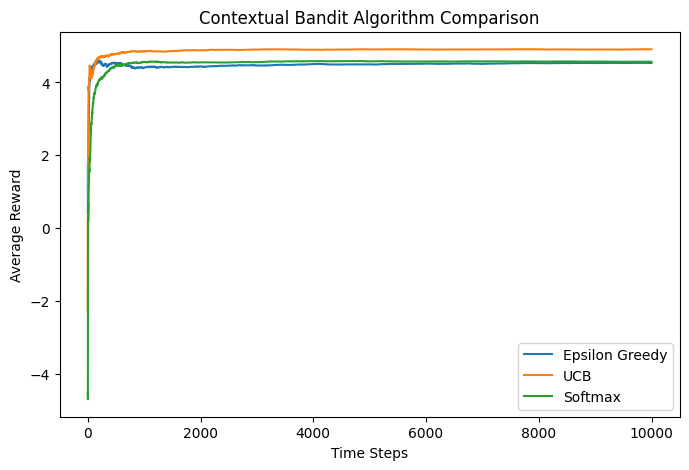

In [31]:
import matplotlib.pyplot as plt

eps_rewards = epsilon_greedy()
ucb_rewards = ucb()
soft_rewards = softmax_bandit()

plt.figure(figsize=(8,5))

plt.plot(eps_rewards, label="Epsilon Greedy")
plt.plot(ucb_rewards, label="UCB")
plt.plot(soft_rewards, label="Softmax")

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Contextual Bandit Algorithm Comparison")
plt.legend()

plt.show()

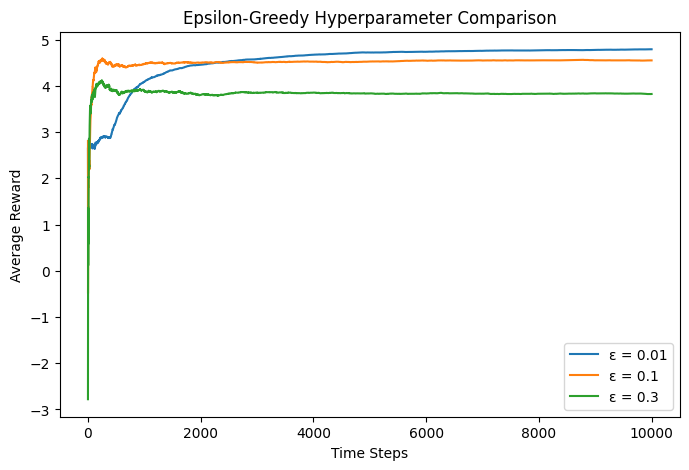

Final Rewards:
ε=0.01: 4.791798355262755
ε=0.1 : 4.550958776027577
ε=0.3 : 3.824208503713907


In [32]:
eps_1 = epsilon_greedy(epsilon=0.01)
eps_2 = epsilon_greedy(epsilon=0.1)
eps_3 = epsilon_greedy(epsilon=0.3)

plt.figure(figsize=(8,5))

plt.plot(eps_1, label="ε = 0.01")
plt.plot(eps_2, label="ε = 0.1")
plt.plot(eps_3, label="ε = 0.3")

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("Epsilon-Greedy Hyperparameter Comparison")
plt.legend()

plt.show()

print("Final Rewards:")
print("ε=0.01:", eps_1[-1])
print("ε=0.1 :", eps_2[-1])
print("ε=0.3 :", eps_3[-1])

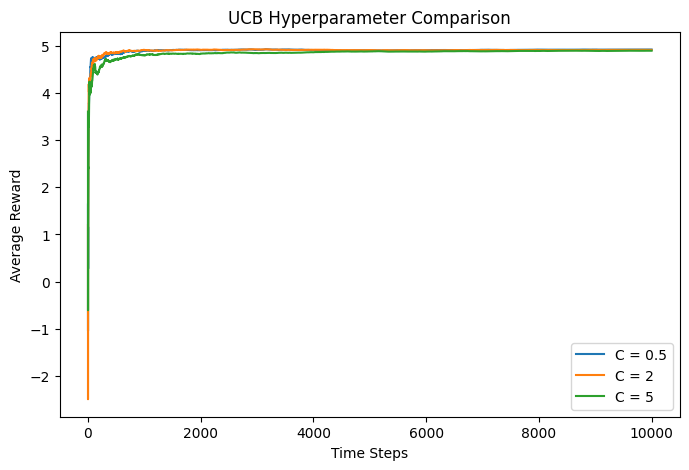

Final Rewards:
C=0.5: 4.916652564578507
C=2  : 4.908808760105264
C=5  : 4.891497673504665


In [33]:
ucb_1 = ucb(C=0.5)
ucb_2 = ucb(C=2)
ucb_3 = ucb(C=5)

plt.figure(figsize=(8,5))

plt.plot(ucb_1, label="C = 0.5")
plt.plot(ucb_2, label="C = 2")
plt.plot(ucb_3, label="C = 5")

plt.xlabel("Time Steps")
plt.ylabel("Average Reward")
plt.title("UCB Hyperparameter Comparison")
plt.legend()

plt.show()

print("Final Rewards:")
print("C=0.5:", ucb_1[-1])
print("C=2  :", ucb_2[-1])
print("C=5  :", ucb_3[-1])

In [34]:
news_df = pd.read_csv("data/news_articles.csv")

allowed_categories = ["ENTERTAINMENT", "EDUCATION", "TECH", "CRIME"]

news_df = news_df[news_df['category'].isin(allowed_categories)].copy()

print("Remaining categories:", news_df['category'].unique())
print("Total articles:", len(news_df))

Remaining categories: ['TECH' 'ENTERTAINMENT' 'EDUCATION' 'CRIME']
Total articles: 24042


In [49]:
def train_ucb_policy(T=10000, C=2):

    counts = np.zeros(12)
    values = np.zeros(12)

    for t in range(T):

        idx = np.random.randint(0, len(train_contexts))
        context = train_contexts[idx]

        start = context * 4
        end = start + 4

        scores = []

        for a in range(start, end):
            if counts[a] == 0:
                scores.append(1e9)
            else:
                scores.append(values[a] + C*np.sqrt(np.log(t+1)/counts[a]))

        action = start + np.argmax(scores)

        reward = reward_sampler.sample(action)

        counts[action] += 1
        values[action] += (reward - values[action]) / counts[action]

    return values

In [50]:
bandit_values = train_ucb_policy()

print("Learned arm values:")
print(bandit_values.reshape(3,4))

Learned arm values:
[[-3.83746856  4.51293281 -0.21836093 -2.79842065]
 [ 0.          0.          0.          0.        ]
 [ 2.44367682 -4.57944996  4.94865114  2.0931094 ]]


In [51]:
category_map = ["ENTERTAINMENT", "EDUCATION", "TECH", "CRIME"]

In [55]:
def recommend(user_row):
    
    # If a Series is passed, convert to 2D DataFrame
    if isinstance(user_row, pd.Series):
        user_row = user_row.to_frame().T

    # Predict context (User1=0, User2=1, User3=2)
    context = clf_model.predict(user_row)[0]

    # Select best arm within that context
    start = context * 4
    end = start + 4

    best_local_arm = np.argmax(bandit_values[start:end])

    #Map local arm to category name
    category_name = category_map[best_local_arm]

    #Randomly sample article from that category
    article = news_df[
        news_df['category'] == category_name
    ].sample(1)

    return category_name, article


In [56]:
print(news_df['category'].unique())

['TECH' 'ENTERTAINMENT' 'EDUCATION' 'CRIME']


In [57]:
cat, art = recommend(X_test.iloc[[0]])



print("Recommended Category:", cat)
print("\nSampled Article:")
print(art)

Recommended Category: TECH

Sampled Article:
                                                     link  \
193194  https://www.huffingtonpost.com/entry/twitter-h...   

                                         headline category  \
193194  15 Things Twitter Tells Us About Humanity     TECH   

                                        short_description             authors  \
193194  Did you know that the world is collectively gr...  Britney Fitzgerald   

              date  
193194  2012-07-22  


C:\Users\mbfeb\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
